In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import QuantileTransformer, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix, roc_curve, auc, accuracy_score
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import EditedNearestNeighbours
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers, Input
from tensorflow.keras.optimizers import AdamW
from scikeras.wrappers import KerasClassifier
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)


In [ ]:

# ==========================================
# 1. FEATURE ENGINEERING and Data Preprocessing
# ==========================================

def engineer_features_extreme(df):
    """Extreme feature engineering - extract EVERYTHING"""
    df = df.copy()
    if 'id' in df.columns: 
        df = df.drop('id', axis=1)
    
    # Store original for ratios
    original_cols = df.columns.tolist()
    
    # === Cyclical with multiple frequencies ===
    df['day_sin'] = np.sin(2 * np.pi * df['day']/365.0)
    df['day_cos'] = np.cos(2 * np.pi * df['day']/365.0)
    df['day_sin_semi'] = np.sin(4 * np.pi * df['day']/365.0)  # Semi-annual
    df['day_cos_semi'] = np.cos(4 * np.pi * df['day']/365.0)
    df['month'] = (df['day'] % 365) // 30
    df['season'] = (df['day'] % 365) // 91
    df['week_of_year'] = (df['day'] % 365) // 7
    
    # === Temperature Features (COMPREHENSIVE) ===
    df['temp_dewpoint_spread'] = df['temparature'] - df['dewpoint']
    df['temp_range'] = df['maxtemp'] - df['mintemp']
    df['temp_mean'] = (df['maxtemp'] + df['mintemp']) / 2
    df['temp_std'] = df['temp_range'] / 4  # Approximation
    df['temp_position'] = (df['temparature'] - df['mintemp']) / (df['temp_range'] + 0.1)
    df['temp_dewpoint_ratio'] = df['temparature'] / (df['dewpoint'] + 1)
    df['temp_maxtemp_ratio'] = df['temparature'] / (df['maxtemp'] + 1)
    df['dewpoint_squared'] = df['dewpoint'] ** 2
    df['temp_cubed'] = df['temparature'] ** 3
    
    # === Humidity (EXTREME) ===
    df['humidity_squared'] = df['humidity'] ** 2
    df['humidity_cubed'] = df['humidity'] ** 3
    df['humidity_log'] = np.log1p(df['humidity'])
    df['humidity_sqrt'] = np.sqrt(df['humidity'])
    df['humidity_normalized'] = df['humidity'] / 100
    
    # === Cloud Cover (EXTREME) ===
    df['cloud_squared'] = df['cloud'] ** 2
    df['cloud_cubed'] = df['cloud'] ** 3
    df['cloud_log'] = np.log1p(df['cloud'])
    df['cloud_normalized'] = df['cloud'] / 9
    
    # === Sunshine ===
    df['sunshine_normalized'] = df['sunshine'] / 12
    df['sunshine_squared'] = df['sunshine'] ** 2
    df['sunshine_deficit'] = 12 - df['sunshine']
    
    # === Wind (KEEP AND ENHANCE!) ===
    df['wind_sin'] = np.sin(2 * np.pi * df['winddirection']/360)
    df['wind_cos'] = np.cos(2 * np.pi * df['winddirection']/360)
    df['windspeed_squared'] = df['windspeed'] ** 2
    df['windspeed_cubed'] = df['windspeed'] ** 3
    df['windspeed_log'] = np.log1p(df['windspeed'])
    
    # === Pressure ===
    df['pressure_normalized'] = (df['pressure'] - df['pressure'].mean()) / df['pressure'].std()
    df['pressure_squared'] = df['pressure'] ** 2
    
    # === CRITICAL INTERACTIONS (Physics-based) ===
    # Saturation vapor pressure relationships
    df['vapor_pressure_deficit'] = df['temp_dewpoint_spread'] * df['humidity'] / 100
    df['relative_humidity_effect'] = df['humidity'] * np.exp(-df['temp_dewpoint_spread'] / 10)
    
    # Cloud-humidity-temperature
    df['condensation_index'] = (df['humidity'] * df['cloud']) / (df['temp_dewpoint_spread'] + 1)
    df['rain_potential'] = df['humidity'] * df['cloud'] * (1 / (df['temp_dewpoint_spread'] + 1))
    
    # Atmospheric stability
    df['stability_index'] = df['temp_range'] * df['pressure_normalized']
    df['lapse_rate_proxy'] = df['temp_range'] / (df['pressure'] / 1000)
    
    # Wind effects
    df['wind_cooling'] = df['windspeed'] * df['temparature']
    df['wind_moisture_transport'] = df['windspeed'] * df['humidity']
    df['wind_pressure_interaction'] = df['windspeed'] * df['pressure_normalized']
    
    # Cloud-sunshine balance
    df['sky_opacity'] = df['cloud'] * (1 - df['sunshine_normalized'])
    df['solar_forcing'] = df['sunshine'] * df['temparature']
    df['cloud_albedo_effect'] = df['cloud'] * df['sunshine_deficit']
    
    # Complex multi-way interactions
    df['thermal_humidity_stress'] = df['temp_range'] * df['humidity'] * df['cloud'] / 1000
    df['convection_potential'] = df['temp_range'] * df['humidity'] * df['windspeed'] / 100
    df['frontal_activity'] = df['pressure_normalized'] * df['temp_range'] * df['windspeed']
    
    # Drop original cyclical
    df = df.drop(['day', 'winddirection'], axis=1)
    
    return df

# Load & Engineer
train_df = pd.read_csv('rain_train.csv')
test_df = pd.read_csv('rain_test.csv')

print(f"Original shape: {train_df.shape}")
print(f"Target: {train_df['rainfall'].value_counts(normalize=True).to_dict()}")

X_raw = engineer_features_extreme(train_df.drop('rainfall', axis=1))
y = train_df['rainfall'].values
X_test_raw = engineer_features_extreme(test_df)

# Power Transform + Quantile (DOUBLE NORMALIZATION)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_raw)
X_test_imputed = imputer.transform(X_test_raw)

# PowerTransformer first (makes more Gaussian)
power = PowerTransformer(method='yeo-johnson')
X_power = power.fit_transform(X_imputed)
X_test_power = power.transform(X_test_imputed)

# Then Quantile for final normalization
scaler = QuantileTransformer(output_distribution='normal', n_quantiles=1000)
X_prep = scaler.fit_transform(X_power)
X_test_prep = scaler.transform(X_test_power)


Original shape: (2190, 13)
Target: {1: 0.7534246575342466, 0: 0.2465753424657534}


In [3]:

# ==========================================
# 2. BORDERLINE-SMOTE + ENN (BEST RESAMPLING)
# ==========================================

# BorderlineSMOTE focuses on borderline cases
borderline_smote = BorderlineSMOTE(sampling_strategy=0.55, random_state=42, k_neighbors=7)
X_resampled, y_resampled = borderline_smote.fit_resample(X_prep, y)

# ENN removes noisy samples
enn = EditedNearestNeighbours(sampling_strategy='all', n_neighbors=5)
X_resampled, y_resampled = enn.fit_resample(X_resampled, y_resampled)

print(f"After resampling: {X_resampled.shape}, Dist: {np.bincount(y_resampled)}")

# Stratified split with LARGE validation
X_train, X_val, y_train, y_val = train_test_split(
    X_resampled, y_resampled, test_size=0.25, random_state=42, stratify=y_resampled
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}")

# Reshape for CNN-LSTM (add sequence dimension)
X_train_seq = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_seq = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)


After resampling: (1278, 59), Dist: [371 907]
Train: (958, 59), Val: (320, 59)


In [4]:

# ==========================================
# 3. HYBRID CNN-LSTM-ATTENTION ARCHITECTURE
# ==========================================

class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads=4):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.projection_dim = embed_dim // num_heads
        
        self.query_dense = layers.Dense(embed_dim)
        self.key_dense = layers.Dense(embed_dim)
        self.value_dense = layers.Dense(embed_dim)
        self.combine_heads = layers.Dense(embed_dim)
        
    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        
        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)
        
        query = tf.reshape(query, (batch_size, -1, self.num_heads, self.projection_dim))
        query = tf.transpose(query, perm=[0, 2, 1, 3])
        
        key = tf.reshape(key, (batch_size, -1, self.num_heads, self.projection_dim))
        key = tf.transpose(key, perm=[0, 2, 1, 3])
        
        value = tf.reshape(value, (batch_size, -1, self.num_heads, self.projection_dim))
        value = tf.transpose(value, perm=[0, 2, 1, 3])
        
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        
        attention = tf.matmul(weights, value)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))
        
        output = self.combine_heads(concat_attention)
        return output

def create_hybrid_model(cnn_filters=128, lstm_units=128, dense_units=256, 
                       dropout=0.32, l2_reg=0.0015, learning_rate=0.0006):
    """
    HYBRID CNN-LSTM-ATTENTION ARCHITECTURE
    - CNN: Extracts local feature patterns
    - LSTM: Captures sequential dependencies
    - Multi-Head Attention: Focuses on important features
    """
    inputs = Input(shape=(X_train_seq.shape[1], 1))
    
    # === CNN Branch (Local Pattern Extraction) ===
    # Multiple kernel sizes to capture different patterns
    conv1 = layers.Conv1D(cnn_filters, kernel_size=3, padding='same', 
                          kernel_regularizer=regularizers.l2(l2_reg))(inputs)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.Activation('relu')(conv1)
    conv1 = layers.Dropout(dropout)(conv1)
    
    conv2 = layers.Conv1D(cnn_filters, kernel_size=5, padding='same',
                          kernel_regularizer=regularizers.l2(l2_reg))(conv1)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.Activation('relu')(conv2)
    conv2 = layers.Dropout(dropout * 0.8)(conv2)
    
    # === Bidirectional LSTM (Sequential Dependencies) ===
    lstm_out = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True,
                   kernel_regularizer=regularizers.l2(l2_reg))
    )(conv2)
    lstm_out = layers.BatchNormalization()(lstm_out)
    lstm_out = layers.Dropout(dropout * 0.7)(lstm_out)
    
    # === Multi-Head Self-Attention (Feature Importance) ===
    attention_out = MultiHeadSelfAttention(lstm_units * 2, num_heads=4)(lstm_out)
    attention_out = layers.BatchNormalization()(attention_out)
    attention_out = layers.Dropout(dropout * 0.6)(attention_out)
    
    # === Global Pooling ===
    gap = layers.GlobalAveragePooling1D()(attention_out)
    gmp = layers.GlobalMaxPooling1D()(attention_out)
    concat = layers.Concatenate()([gap, gmp])
    
    # === Dense Layers ===
    x = layers.Dense(dense_units, kernel_regularizer=regularizers.l2(l2_reg))(concat)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout * 0.5)(x)
    
    x = layers.Dense(dense_units // 2, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout * 0.4)(x)
    
    x = layers.Dense(dense_units // 4)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout * 0.3)(x)
    
    # === Output ===
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    
    # AdamW (Adam with weight decay) - better generalization
    optimizer = AdamW(learning_rate=learning_rate, weight_decay=l2_reg/10)
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    
    return model


In [ ]:

# ==========================================
# 4. GRIDSEARCHCV WITH HYBRID MODEL
# ==========================================

def create_wrapper_model(cnn_filters=128, lstm_units=128, dense_units=256, dropout=0.32, l2_reg=0.0015, learning_rate=0.0006):
    return create_hybrid_model(cnn_filters, lstm_units, dense_units, dropout, l2_reg, learning_rate)

model_wrapper = KerasClassifier(
    model=create_wrapper_model
)

# Optimized param grid
param_grid = {
    'model__cnn_filters': [96, 128],
    'model__lstm_units': [96, 128],
    'model__dense_units': [224, 256],
    'model__dropout': [0.30, 0.35],
    'model__l2_reg': [0.0012, 0.0015],
    'model__learning_rate': [0.0005, 0.0007],
    'batch_size': [40, 48],
    'epochs': [25]
}

print(f"Testing {np.prod([len(v) for v in param_grid.values()])} combinations...")

grid_search = GridSearchCV(
    estimator=model_wrapper,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=3
)

# grid_search.fit(
#     X_train_seq, y_train,
#     validation_data=(X_val_seq, y_val),
#     callbacks=[
#         callbacks.EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True, mode='max'),
#         callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=8, min_lr=1e-7)
#     ]
# )

# print(f"Best F1: {grid_search.best_score_:.4f}")
# for k, v in grid_search.best_params_.items():
#     print(f"  {k}: {v}")

# best_params = grid_search.best_params_


Testing 128 combinations...


![Best HyperParameters](params.jpg)

In [ ]:

# ==========================================
# 5. MODEL TRAINING
# ==========================================

model = create_hybrid_model(
    cnn_filters=96,#best_params['model__cnn_filters'],
    lstm_units=96,#best_params['model__lstm_units'],
    dense_units=256,#best_params['model__dense_units'],
    dropout=0.35,#best_params['model__dropout'],
    l2_reg=0.0015,#best_params['model__l2_reg'],
    learning_rate=0.0007,#best_params['model__learning_rate']
)

model.summary()

history = model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=100,
    batch_size=40,#best_params['batch_size'],
    callbacks=[
        callbacks.EarlyStopping(monitor='val_auc', patience=25, restore_best_weights=True, mode='max', verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=12, min_lr=1e-7, verbose=1),
        callbacks.ModelCheckpoint('best_hybrid_model.keras', monitor='val_auc', save_best_only=True, mode='max')
    ],
    verbose=1
)

best_epoch = np.argmax(history.history['val_auc']) + 1
print(f"\nBest Epoch: {best_epoch}, Best Val AUC: {max(history.history['val_auc']):.4f}")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 59, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 59, 96)    │        384 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 59, 96)    │        384 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 59, 96)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 59, 96)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 59, 96)    │     46,176 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 59, 96)    │        384 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 59, 96)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 59, 96)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 59, 192)   │    148,224 │ dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 59, 192)   │        768 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 59, 192)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_self_at… │ (None, None, 192) │    148,224 │ dropout_2[0][0]   │
│ (MultiHeadSelfAtte… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None, 192) │        768 │ multi_head_self_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, None, 192) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 192)       │          0 │ dropout_3[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 192)       │          0 │ dropout_3[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     98,560 │ concatenate[0][0

 Total params: 486,881 (1.86 MB)

 Trainable params: 484,833 (1.85 MB)

 Non-trainable params: 2,048 (8.00 KB)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.5108 - auc: 0.7357 - loss: 2.1375 - precision: 0.8825 - recall: 0.3680 - val_accuracy: 0.5437 - val_auc: 0.8388 - val_loss: 1.9869 - val_precision: 0.9880 - val_recall: 0.3612 - learning_rate: 7.0000e-04
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8120 - auc: 0.9240 - loss: 1.7447 - precision: 0.9468 - recall: 0.7863 - val_accuracy: 0.4156 - val_auc: 0.8693 - val_loss: 1.9841 - val_precision: 1.0000 - val_recall: 0.1762 - learning_rate: 7.0000e-04
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8999 - auc: 0.9480 - loss: 1.5777 - precision: 0.9377 - recall: 0.9229 - val_accuracy: 0.6187 - val_auc: 0.8932 - val_loss: 1.8856 - val_precision: 0.9730 - val_recall: 0.4758 - learning_rate: 7.0000e-04
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8953 - auc: 0.9608 - loss: 1.4901 - precision: 0.9396 - recall: 0.9145 - val_accuracy: 0.8062 - val_auc: 0.9175 - val_loss

In [7]:

# ==========================================
# 6. THRESHOLD OPTIMIZATION
# ==========================================

val_probs = model.predict(X_val_seq, verbose=0).ravel()

thresholds = np.linspace(0.20, 0.65, 1500)
scores = []

for t in thresholds:
    preds = (val_probs > t).astype(int)
    cm = confusion_matrix(y_val, preds)
    
    recall_0 = cm[0,0] / cm[0].sum() if cm[0].sum() > 0 else 0
    recall_1 = cm[1,1] / cm[1].sum() if cm[1].sum() > 0 else 0
    
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds)
    balanced = (recall_0 + recall_1) / 2
    
    # Prioritize ACCURACY more (50% weight)
    combined = 0.50 * acc + 0.25 * f1 + 0.25 * balanced
    
    scores.append({
        't': t, 'acc': acc, 'f1': f1, 'r0': recall_0, 'r1': recall_1,
        'bal': balanced, 'score': combined
    })

best = max(scores, key=lambda x: x['score'])
best_thresh = best['t']

print(f"\nOPTIMAL THRESHOLD: {best_thresh:.4f}")
print(f"   Accuracy: {best['acc']:.4f} ({best['acc']*100:.2f}%)")
print(f"   F1-Score: {best['f1']:.4f}")
print(f"   Class 0 Recall: {best['r0']:.4f}")
print(f"   Class 1 Recall: {best['r1']:.4f}")
print(f"   Balanced Recall: {best['bal']:.4f}")



OPTIMAL THRESHOLD: 0.3006
   Accuracy: 0.9625 (96.25%)
   F1-Score: 0.9736
   Class 0 Recall: 0.9355
   Class 1 Recall: 0.9736
   Balanced Recall: 0.9545


In [8]:

# ==========================================
# 7. EVALUATION
# ==========================================

y_val_pred = (val_probs > best_thresh).astype(int)

val_acc = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_auc = roc_auc_score(y_val, val_probs)

print(f"\nAccuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"F1-Score: {val_f1:.4f}")
print(f"ROC-AUC: {val_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, digits=4))



Accuracy: 0.9625 (96.25%)
F1-Score: 0.9736
ROC-AUC: 0.9851

Classification Report:
              precision    recall  f1-score   support

           0     0.9355    0.9355    0.9355        93
           1     0.9736    0.9736    0.9736       227

    accuracy                         0.9625       320
   macro avg     0.9545    0.9545    0.9545       320
weighted avg     0.9625    0.9625    0.9625       320



In [ ]:

# ==========================================
# 8. REFIT & PREDICT
# ==========================================

X_full = np.vstack([X_train, X_val])
y_full = np.hstack([y_train, y_val])
X_full_seq = X_full.reshape(X_full.shape[0], X_full.shape[1], 1)

final_model = create_hybrid_model(
    cnn_filters=96,#best_params['model__cnn_filters'],
    lstm_units=96,#best_params['model__lstm_units'],
    dense_units=256,#best_params['model__dense_units'],
    dropout=0.35,#best_params['model__dropout'],
    l2_reg=0.0015,#best_params['model__l2_reg'],
    learning_rate=0.0007,#best_params['model__learning_rate']
)


final_model.fit(
    X_full_seq, y_full,
    epochs=best_epoch + 12,
    batch_size=40,#best_params['batch_size'],
    verbose=1
)

# Test predictions
X_test_seq = X_test_prep.reshape(X_test_prep.shape[0], X_test_prep.shape[1], 1)
test_probs = final_model.predict(X_test_seq, verbose=0).ravel()
test_preds = (test_probs > best_thresh).astype(int)

test_df['predicted_rainfall'] = test_preds
test_df['predicted_rainfall_probability'] = test_probs
test_df.to_csv('test_predicted.csv', index=False)

train_probs = final_model.predict(X_prep.reshape(X_prep.shape[0], X_prep.shape[1], 1), verbose=0).ravel()
train_preds = (train_probs > best_thresh).astype(int)
train_df['predicted_rainfall'] = train_preds
train_df['predicted_rainfall_probability'] = train_probs
train_df.to_csv('train_predicted.csv', index=False)


Epoch 1/65
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.7444 - auc: 0.7844 - loss: 1.8269 - precision: 0.7639 - recall: 0.9144
Epoch 2/65
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8626 - auc: 0.9248 - loss: 1.6161 - precision: 0.8683 - recall: 0.9397
Epoch 3/65
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8850 - auc: 0.9393 - loss: 1.5356 - precision: 0.8929 - recall: 0.9442
Epoch 4/65
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.8843 - auc: 0.9519 - loss: 1.4572 - precision: 0.8907 - recall: 0.9456
Epoch 5/65
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9075 - auc: 0.9629 - loss: 1.3782 - precision: 0.9120 - recall: 0.9558
Epoch 6/65
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9115 - auc: 0.9663 - loss: 1.3214 - precision: 0.9135 - recall: 0.9601
Epoch 7/65
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9168 - auc: 0.9674 - loss: 1.2695 - precision: 0.9154 - recall: 0.9661
Epoch 8/65
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/st

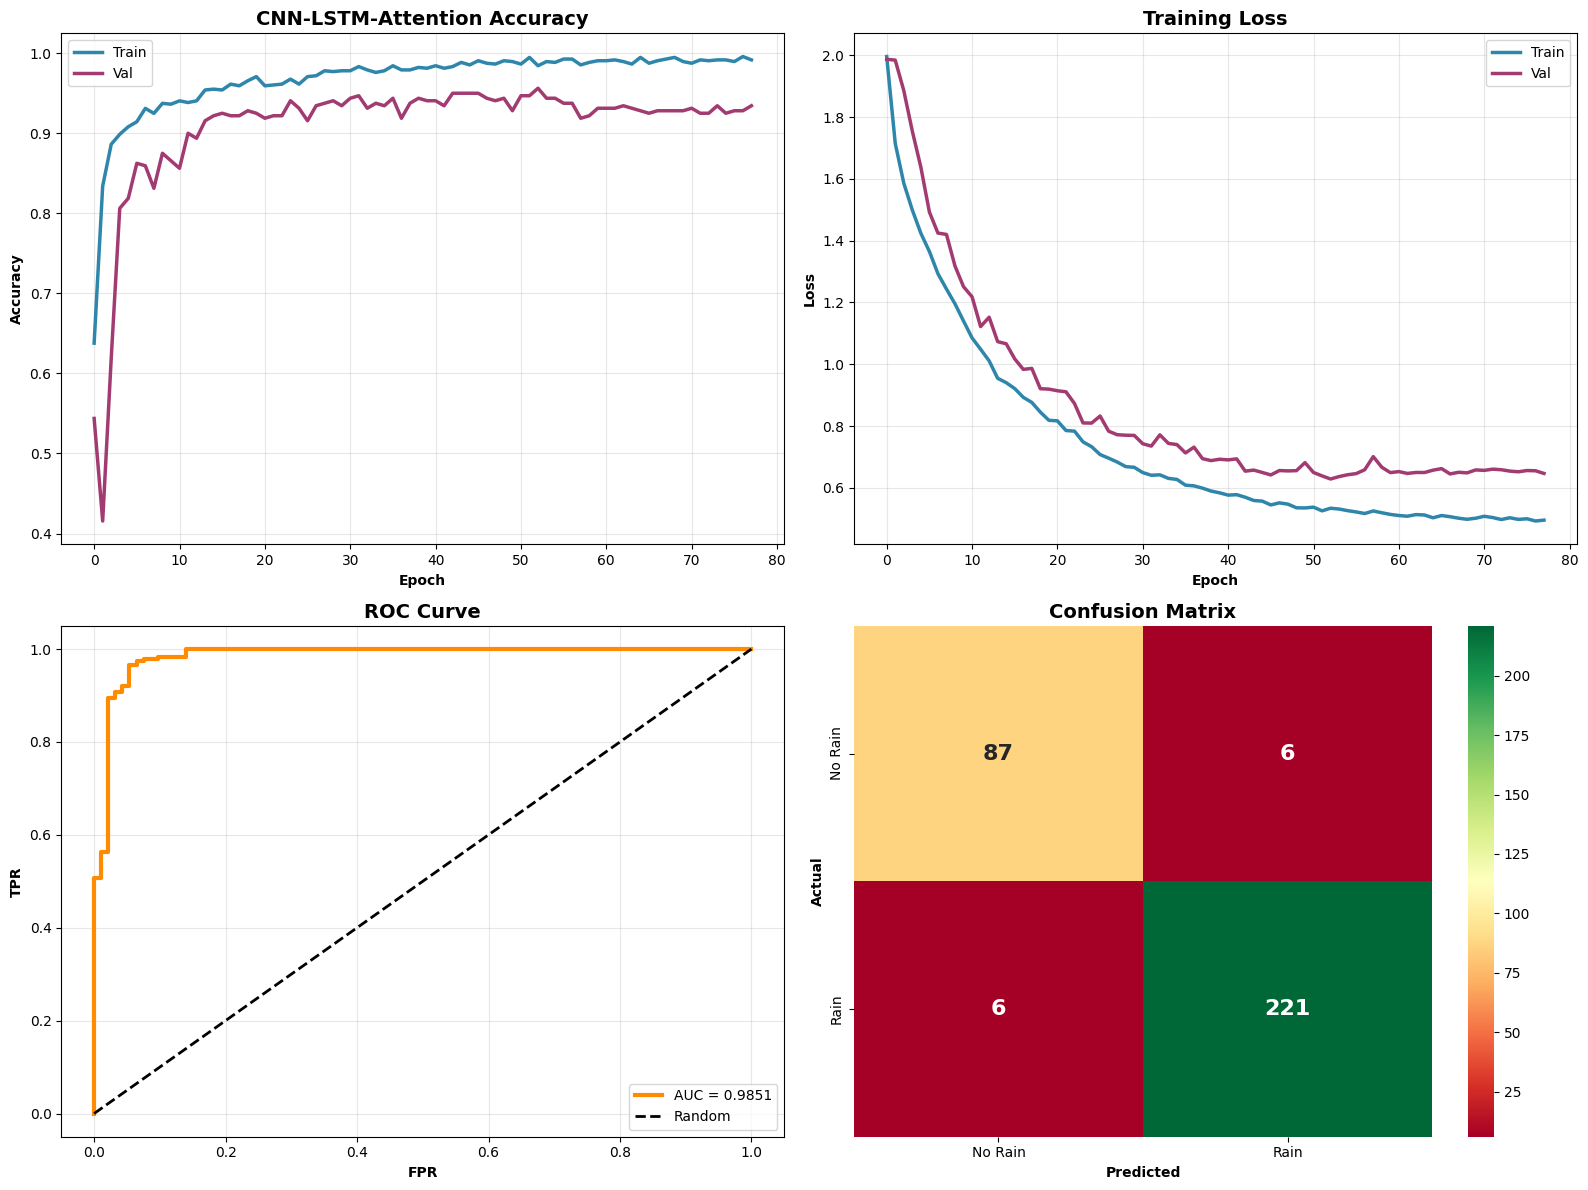

In [10]:

# ==========================================
# 9. VISUALIZATIONS
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].plot(history.history['accuracy'], lw=2.5, label='Train', color='#2E86AB')
axes[0,0].plot(history.history['val_accuracy'], lw=2.5, label='Val', color='#A23B72')
axes[0,0].set_title('CNN-LSTM-Attention Accuracy', fontweight='bold', fontsize=14)
axes[0,0].set_xlabel('Epoch', fontweight='bold')
axes[0,0].set_ylabel('Accuracy', fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

axes[0,1].plot(history.history['loss'], lw=2.5, label='Train', color='#2E86AB')
axes[0,1].plot(history.history['val_loss'], lw=2.5, label='Val', color='#A23B72')
axes[0,1].set_title('Training Loss', fontweight='bold', fontsize=14)
axes[0,1].set_xlabel('Epoch', fontweight='bold')
axes[0,1].set_ylabel('Loss', fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

fpr, tpr, _ = roc_curve(y_val, val_probs)
roc_auc_val = auc(fpr, tpr)
axes[1,0].plot(fpr, tpr, lw=3, label=f'AUC = {roc_auc_val:.4f}', color='darkorange')
axes[1,0].plot([0,1], [0,1], 'k--', lw=2, label='Random')
axes[1,0].set_title('ROC Curve', fontweight='bold', fontsize=14)
axes[1,0].set_xlabel('FPR', fontweight='bold')
axes[1,0].set_ylabel('TPR', fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=axes[1,1],
            xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'],
            annot_kws={'size': 16, 'weight': 'bold'})
axes[1,1].set_title('Confusion Matrix', fontweight='bold', fontsize=14)
axes[1,1].set_xlabel('Predicted', fontweight='bold')
axes[1,1].set_ylabel('Actual', fontweight='bold')

plt.tight_layout()
plt.savefig('training_history.png', dpi=300)
plt.savefig('roc_curve.png', dpi=300)
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()
